# Barebone linear $P_{mm}$ and $P_{cb}$ vs CLASS

Loads the `Pk_lin_mm` and `Pk_lin_cb` emulator components individually, evaluates linear power spectra at 5 redshifts, and compares against CLASS.

In [1]:
import os, sys
from contextlib import contextmanager

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from classy import Class

import jaxmapse

In [2]:
#--- Cosmology (flat ΛCDM) ---
cosmo = {
    "ln10As":  3.044,
    "ns":      0.9649,
    "H0":      67.36,
    "omega_b": 0.02237,
    "omega_c": 0.12,
    "Mnu":     0.06,
    "w0":     -1.0,
    "wa":      0.0,
}

# Emulator parameter vector order:
# [ln10As, ns, H0, omega_b, omega_c, Mnu, w0, wa]
params = jnp.array([
    cosmo["ln10As"], cosmo["ns"], cosmo["H0"],
    cosmo["omega_b"], cosmo["omega_c"], cosmo["Mnu"],
    cosmo["w0"], cosmo["wa"],
])

z_eval = jnp.array([0.0, 1.0, 2.0, 3.0, 4.0])

In [3]:
trained = jaxmapse.load_trained_emulators()[jaxmapse.DEFAULT_EMULATOR_ARTIFACT]
pmm = trained["pmm"]
pcb = trained["pcb"]

k = np.asarray(pmm.k_grid)
print("k grid:", k.shape, k.min(), k.max())


k grid: (300,) 4.9999999999999996e-06 100.0


In [4]:
h = cosmo["H0"] / 100.0
jax_cosmo = jaxmapse.w0waCDMCosmology(
    ln10As=cosmo["ln10As"],
    ns=cosmo["ns"],
    h=h,
    omega_b=cosmo["omega_b"],
    omega_c=cosmo["omega_c"],
    m_nu=cosmo["Mnu"],
    w0=cosmo["w0"],
    wa=cosmo["wa"],
)
D_eval = jnp.asarray(jax_cosmo.D_z(z_eval))
print("D(z):", np.asarray(D_eval))

D(z): [0.77129877 0.46860294 0.32251206 0.24406407 0.19596748]


In [5]:
# Shape: (len(z), len(k))
Pmm_emu = np.asarray(pmm(params, z_eval, D_eval))
Pcb_emu = np.asarray(pcb(params, z_eval, D_eval))
print("Pmm_emu:", Pmm_emu.shape, "  Pcb_emu:", Pcb_emu.shape)

Pmm_emu: (5, 300)   Pcb_emu: (5, 300)


## CLASS reference

In [6]:
@contextmanager
def suppress_c_output():
    sys.stdout.flush(); sys.stderr.flush()
    old1, old2 = os.dup(1), os.dup(2)
    try:
        with open(os.devnull, "w") as devnull:
            os.dup2(devnull.fileno(), 1); os.dup2(devnull.fileno(), 2)
            yield
    finally:
        os.dup2(old1, 1); os.dup2(old2, 2)
        os.close(old1); os.close(old2)

def class_params(cosmo, z_max, k_max):
    return {
        "output": "mPk",
        "P_k_max_1/Mpc": float(k_max),
        "z_max_pk": float(z_max),
        "h": cosmo["H0"] / 100.0,
        "omega_b": cosmo["omega_b"],
        "omega_cdm": cosmo["omega_c"],
        "N_ur": 2.0328,
        "N_ncdm": 1,
        "m_ncdm": cosmo["Mnu"],
        "tau_reio": 0.0544,
        "A_s": float(np.exp(cosmo["ln10As"]) * 1e-10),
        "n_s": cosmo["ns"],
        "w0_fld": cosmo["w0"],
        "wa_fld": cosmo["wa"],
        "Omega_Lambda": 0.0,
        "fluid_equation_of_state": "CLP",
        "use_ppf": "yes",
    }

def run_class(cosmo, z_eval, k):
    c = Class()
    c.set(class_params(cosmo, z_max=float(np.max(z_eval)) + 0.5, k_max=float(np.max(k) * 1.05)))
    with suppress_c_output():
        c.compute()
        Pmm = np.array([[c.pk_lin(float(kk), float(zz)) for kk in k] for zz in z_eval])
        Pcb = np.array([[c.pk_cb_lin(float(kk), float(zz)) for kk in k] for zz in z_eval])
    c.struct_cleanup(); c.empty()
    return Pmm, Pcb

In [7]:
Pmm_class, Pcb_class = run_class(cosmo, np.asarray(z_eval), k)
print("CLASS Pmm:", Pmm_class.shape, "  CLASS Pcb:", Pcb_class.shape)

CLASS Pmm: (5, 300)   CLASS Pcb: (5, 300)


## Residuals

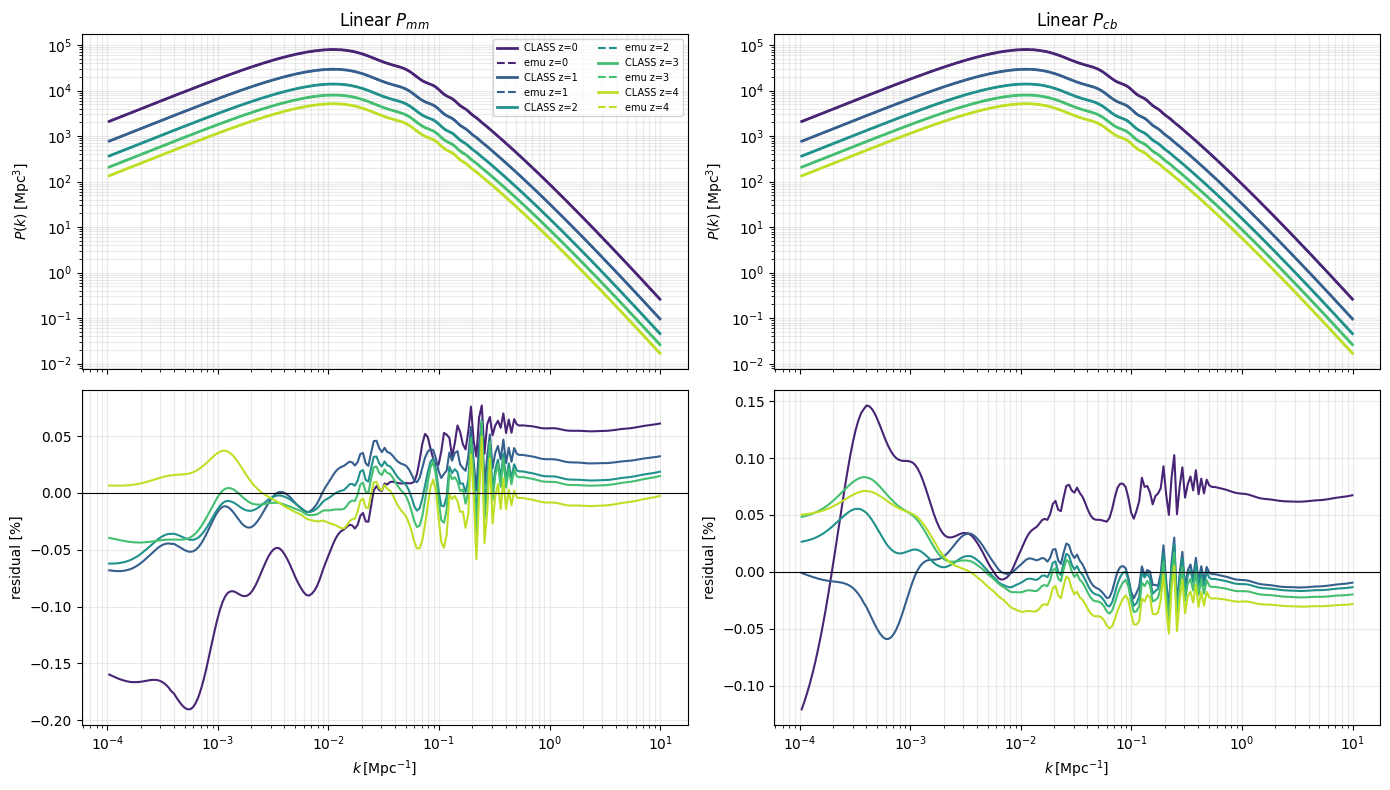

In [8]:
mask = (k >= 1e-4) & (k <= 10.0)
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(z_eval)))

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex="col")

for col, (title, emu_pk, class_pk) in enumerate([
    (r"Linear $P_{mm}$", Pmm_emu, Pmm_class),
    (r"Linear $P_{cb}$", Pcb_emu, Pcb_class),
]):
    ax_top = axes[0, col]
    ax_res = axes[1, col]
    for iz, (zz, color) in enumerate(zip(z_eval, colors)):
        ax_top.loglog(k[mask], class_pk[iz, mask], color=color, lw=2, label=f"CLASS z={zz:g}")
        ax_top.loglog(k[mask],   emu_pk[iz, mask], color=color, ls="--", lw=1.5, label=f"emu z={zz:g}")
        rel = 100.0 * (emu_pk / class_pk - 1.0)
        ax_res.semilogx(k[mask], rel[iz, mask], color=color, lw=1.5)
    ax_top.set_title(title)
    ax_top.set_ylabel(r"$P(k)\;[{\rm Mpc}^3]$")
    ax_top.grid(True, which="both", alpha=0.25)
    ax_res.axhline(0.0, color="k", lw=0.8)
    ax_res.set_xlabel(r"$k\,[{\rm Mpc}^{-1}]$")
    ax_res.set_ylabel("residual [%]")
    ax_res.grid(True, which="both", alpha=0.25)

axes[0, 0].legend(fontsize=7, ncol=2)
fig.tight_layout()
plt.show()